# 📊 Sales & Revenue Analysis Dashboard

## Project Overview

This project analyzes sales and revenue data using Python and Jupyter Notebook.

### Key Analysis
- Total Revenue
- Total Units Sold
- Monthly Revenue Trends
- Top-Performing Products
- Revenue by Region
- Revenue by Category
- Salesperson Performance
- Interactive Filters

### Technologies Used
Python | Pandas | NumPy | Plotly | Jupyter Notebook

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_excel("data/sales_data.xlsx")
df.head()

,Date,Region,Category,Product,Salesperson,Quantity,Unit Price,Revenue
0,2026-01-05,North,Electronics,Laptop,Alice,2,750,1500
1,2026-01-08,South,Furniture,Office Chair,Bob,5,120,600
2,2026-01-12,East,Electronics,Headphones,Carol,10,45,450
3,2026-01-18,West,Office Supplies,Notebook,David,25,8,200
4,2026-02-03,North,Electronics,Monitor,Alice,4,220,880


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 24
Number of columns: 8

Column names:
['Date', 'Region', 'Category', 'Product', 'Salesperson', 'Quantity', 'Unit Price', 'Revenue']

Data types:
Date           object
Region         object
Category       object
Product        object
Salesperson    object
Quantity        int64
Unit Price      int64
Revenue         int64
dtype: object


In [4]:
df.isnull().sum()

Date           0
Region         0
Category       0
Product        0
Salesperson    0
Quantity       0
Unit Price     0
Revenue        0
dtype: int64

In [5]:
df.describe()

,Quantity,Unit Price,Revenue
count,24.000000,24.000000,24.000000
mean,15.000000,186.250000,968.125000
std,13.048405,239.903649,692.457521
min,2.000000,8.000000,200.000000
25%,5.000000,29.250000,420.000000
50%,10.000000,82.500000,825.000000
75%,20.500000,240.000000,1365.000000
max,50.000000,750.000000,3000.000000


In [6]:
# Calculate KPIs

total_revenue = df["Revenue"].sum()
total_units = df["Quantity"].sum()
total_transactions = len(df)
average_revenue = df["Revenue"].mean()

# Find the top product
top_product = (
    df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("===== SALES & REVENUE KPIs =====")
print("Total Revenue      :", f"${total_revenue:,.2f}")
print("Total Units Sold   :", f"{total_units:,}")
print("Total Transactions :", f"{total_transactions:,}")
print("Average Revenue    :", f"${average_revenue:,.2f}")
print("Top Product        :", top_product.index[0])

===== SALES & REVENUE KPIs =====
Total Revenue      : $23,235.00
Total Units Sold   : 360
Total Transactions : 24
Average Revenue    : $968.12
Top Product        : Laptop


In [7]:
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Region,Category,Product,Salesperson,Quantity,Unit Price,Revenue
0,2026-01-05,North,Electronics,Laptop,Alice,2,750,1500
1,2026-01-08,South,Furniture,Office Chair,Bob,5,120,600
2,2026-01-12,East,Electronics,Headphones,Carol,10,45,450
3,2026-01-18,West,Office Supplies,Notebook,David,25,8,200
4,2026-02-03,North,Electronics,Monitor,Alice,4,220,880


In [8]:
monthly_revenue = (
    df.groupby(df["Date"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["Date"] = monthly_revenue["Date"].astype(str)

monthly_revenue

,Date,Revenue
0,2026-01,2750
1,2026-02,2440
2,2026-03,4205
3,2026-04,3810
4,2026-05,5500
5,2026-06,4530


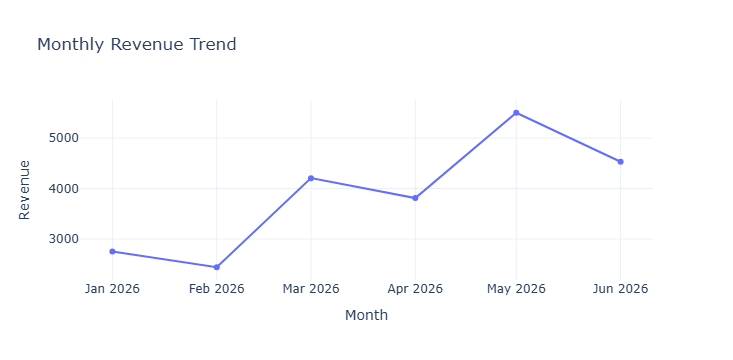

In [9]:
fig = px.line(
    monthly_revenue,
    x="Date",
    y="Revenue",
    markers=True,
    title="Monthly Revenue Trend"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Revenue",
    template="plotly_white"
)

fig.show()

In [11]:
product_revenue = (
    df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue

Product
Laptop           6750
Desk             4200
Monitor          3740
Office Chair     2760
Headphones       2025
Keyboard         1820
Printer Paper    1020
Notebook          920
Name: Revenue, dtype: int64

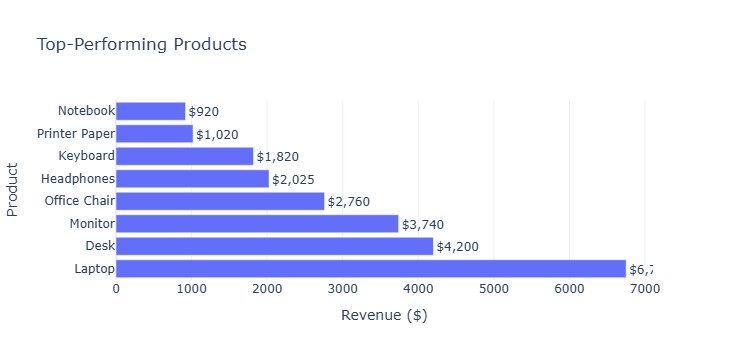

In [12]:
fig = px.bar(
    product_revenue.reset_index(),
    x="Revenue",
    y="Product",
    orientation="h",
    title="Top-Performing Products",
    text="Revenue"
)

fig.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Revenue ($)",
    yaxis_title="Product",
    template="plotly_white"
)

fig.show()

In [13]:
region_revenue = (
    df.groupby("Region")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

region_revenue

Region
North    10490
South     6960
East      3845
West      1940
Name: Revenue, dtype: int64

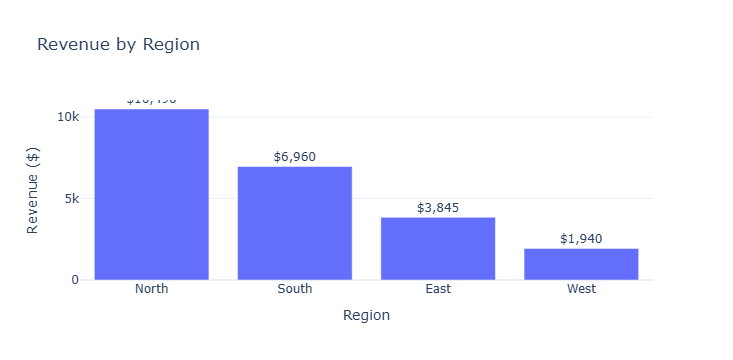

In [14]:
fig = px.bar(
    region_revenue.reset_index(),
    x="Region",
    y="Revenue",
    title="Revenue by Region",
    text="Revenue"
)

fig.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Region",
    yaxis_title="Revenue ($)",
    template="plotly_white"
)

fig.show()

In [15]:
category_revenue = (
    df.groupby("Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Category
Electronics        14335
Furniture           6960
Office Supplies     1940
Name: Revenue, dtype: int64

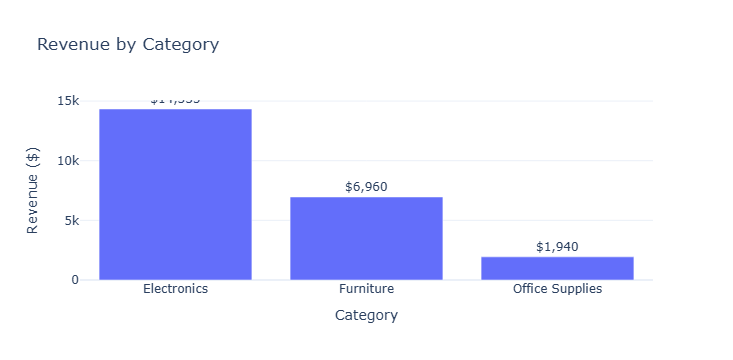

In [16]:
fig = px.bar(
    category_revenue.reset_index(),
    x="Category",
    y="Revenue",
    title="Revenue by Category",
    text="Revenue"
)

fig.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Category",
    yaxis_title="Revenue ($)",
    template="plotly_white"
)

fig.show()

In [17]:
salesperson_revenue = (
    df.groupby("Salesperson")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

salesperson_revenue

Salesperson
Alice    10490
Bob       6960
Carol     3845
David     1940
Name: Revenue, dtype: int64

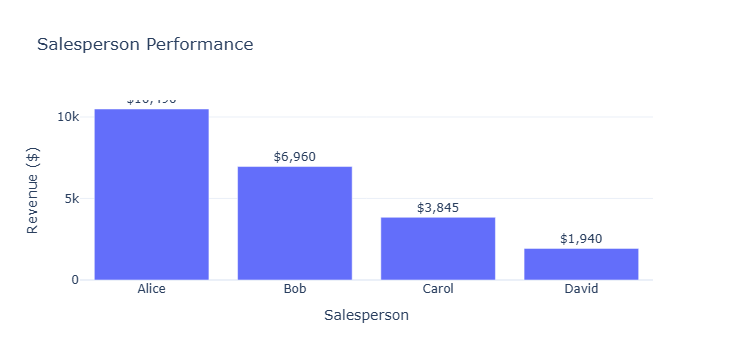

In [18]:
fig = px.bar(
    salesperson_revenue.reset_index(),
    x="Salesperson",
    y="Revenue",
    title="Salesperson Performance",
    text="Revenue"
)

fig.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Salesperson",
    yaxis_title="Revenue ($)",
    template="plotly_white"
)

fig.show()

In [19]:
# ==========================================
# SALES & REVENUE ANALYSIS DASHBOARD
# ==========================================

# Calculate KPIs
total_revenue = df["Revenue"].sum()
total_units = df["Quantity"].sum()
total_transactions = len(df)
average_revenue = df["Revenue"].mean()

top_product = (
    df.groupby("Product")["Revenue"]
    .sum()
    .idxmax()
)

# Display dashboard title
print("=" * 65)
print("             SALES & REVENUE ANALYSIS DASHBOARD")
print("=" * 65)

# Display KPIs
print(f"💰 Total Revenue       : ${total_revenue:,.2f}")
print(f"📦 Total Units Sold    : {total_units:,}")
print(f"🧾 Total Transactions  : {total_transactions:,}")
print(f"📈 Average Revenue     : ${average_revenue:,.2f}")
print(f"🏆 Top Product         : {top_product}")

print("=" * 65)

             SALES & REVENUE ANALYSIS DASHBOARD
💰 Total Revenue       : $23,235.00
📦 Total Units Sold    : 360
🧾 Total Transactions  : 24
📈 Average Revenue     : $968.12
🏆 Top Product         : Laptop


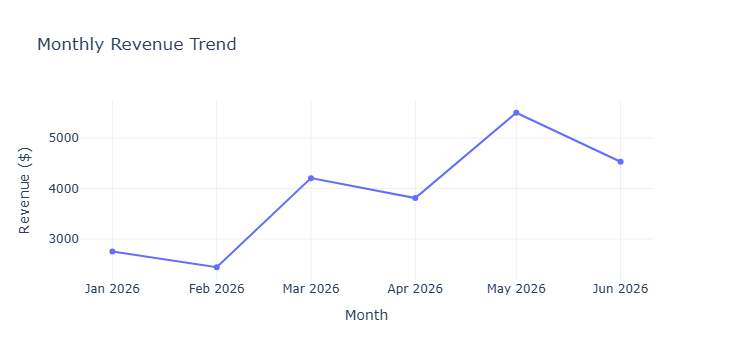

In [20]:
# Monthly Revenue Trend

monthly_revenue = (
    df.groupby(df["Date"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["Date"] = monthly_revenue["Date"].astype(str)

fig = px.line(
    monthly_revenue,
    x="Date",
    y="Revenue",
    markers=True,
    title="Monthly Revenue Trend"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="Revenue ($)"
)

fig.show()

In [21]:
!pip install ipywidgets

In [22]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [23]:
region_filter = widgets.Dropdown(
    options=["All"] + sorted(df["Region"].unique().tolist()),
    description="Region:"
)

category_filter = widgets.Dropdown(
    options=["All"] + sorted(df["Category"].unique().tolist()),
    description="Category:"
)

product_filter = widgets.Dropdown(
    options=["All"] + sorted(df["Product"].unique().tolist()),
    description="Product:"
)

display(region_filter)
display(category_filter)
display(product_filter)

Dropdown(description='Region:', options=('All', 'East', 'North', 'South', 'West'), value='All')

Dropdown(description='Category:', options=('All', 'Electronics', 'Furniture', 'Office Supplies'), value='All')

Dropdown(description='Product:', options=('All', 'Desk', 'Headphones', 'Keyboard', 'Laptop', 'Monitor', 'Noteb…

In [24]:
def update_dashboard(region, category, product):
    
    filtered_df = df.copy()

    if region != "All":
        filtered_df = filtered_df[
            filtered_df["Region"] == region
        ]

    if category != "All":
        filtered_df = filtered_df[
            filtered_df["Category"] == category
        ]

    if product != "All":
        filtered_df = filtered_df[
            filtered_df["Product"] == product
        ]

    # KPIs
    revenue = filtered_df["Revenue"].sum()
    units = filtered_df["Quantity"].sum()
    transactions = len(filtered_df)

    print("========== FILTERED DASHBOARD ==========")
    print(f"Total Revenue      : ${revenue:,.2f}")
    print(f"Units Sold         : {units:,}")
    print(f"Transactions       : {transactions:,}")
    print("========================================")

    # Revenue by product
    product_data = (
        filtered_df.groupby("Product")["Revenue"]
        .sum()
        .reset_index()
        .sort_values("Revenue", ascending=False)
    )

    fig = px.bar(
        product_data,
        x="Product",
        y="Revenue",
        title="Revenue by Product",
        text="Revenue"
    )

    fig.update_traces(
        texttemplate="$%{text:,.0f}",
        textposition="outside"
    )

    fig.show()

In [25]:
widgets.interactive(
    update_dashboard,
    region=region_filter,
    category=category_filter,
    product=product_filter
)

interactive(children=(Dropdown(description='Region:', options=('All', 'East', 'North', 'South', 'West'), value…